
 MODEL
R2 Score: 0.9771
RMSE: 6.16


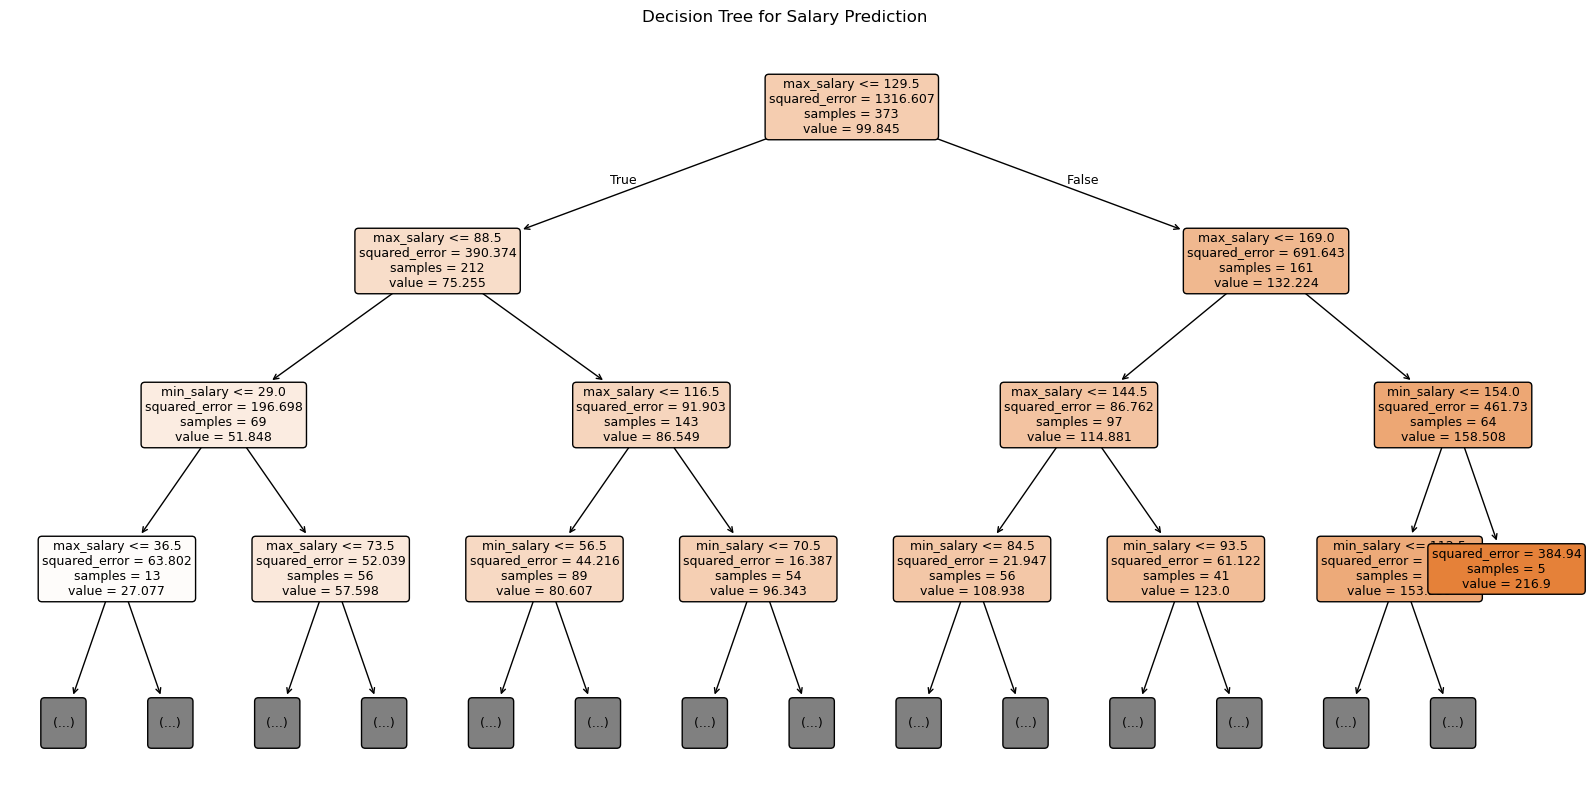


 TOP 10 FEATURES AFFECTING SALARY 
        Feature  Importance
11   max_salary    0.916171
10   min_salary    0.083267
13    job_state    0.000473
12  company_txt    0.000065
4      industry    0.000025
19          aws    0.000000
18        spark    0.000000
17         r_yn    0.000000
16    python_yn    0.000000
15          age    0.000000


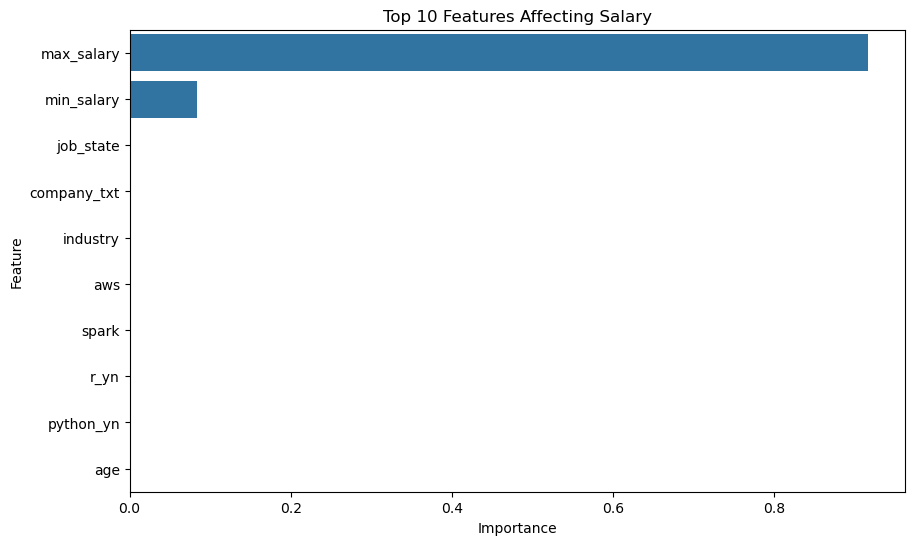

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('salary_data_final_cleaned.csv')

cols_to_drop = ['job_title', 'salary_estimate', 'job_description', 'company_name', 'location', 'headquarters']
df = df.drop(columns=cols_to_drop, errors='ignore')

df = df.fillna(df.median(numeric_only=True))

le_dict = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

TARGET = 'avg_salary' # <-- THIS IS YOUR TARGET
X = df.drop(TARGET, axis=1)
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeRegressor(max_depth=6, min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("\n MODEL")
print("R2 Score:", round(r2_score(y_test, y_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred)), 2))

plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=X.columns, filled=True, rounded=True, fontsize=9, max_depth=3)
plt.title("Decision Tree for Salary Prediction")
plt.show()

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n TOP 10 FEATURES AFFECTING SALARY ")
print(importance.head(10))

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance.head(10))
plt.title('Top 10 Features Affecting Salary')
plt.show()

df['Predicted_Salary'] = dt.predict(df[X.columns])
df.to_csv('salary_with_predictions.csv', index=False)
